In [1]:
from google.colab import files
uploaded = files.upload()


Saving cleanedno2newusdc 2.csv to cleanedno2newusdc 2.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(list(uploaded.keys())[0])
df.head()


,Date,Time,NO2(GT),PT08.S4(NO2),Temperature (C),Relative Humidity,Absolute Humidity,Datetime
0,2004-03-10,18:00:00,0.328402,0.513040,0.333333,0.499371,0.280066,2004-03-10 18:00:00
1,2004-03-10,19:00:00,0.266272,0.453237,0.326882,0.484277,0.264282,2004-03-10 19:00:00
2,2004-03-10,20:00:00,0.331361,0.451439,0.296774,0.563522,0.276352,2004-03-10 20:00:00
3,2004-03-10,21:00:00,0.355030,0.464478,0.277419,0.638994,0.294190,2004-03-10 21:00:00
4,2004-03-10,22:00:00,0.337278,0.422212,0.281720,0.633962,0.295216,2004-03-10 22:00:00


In [3]:
df.columns = df.columns.astype(str).str.strip()

if "Datetime" not in df.columns:
    df["Datetime"] = pd.to_datetime(
        df["Date"].astype(str) + " " + df["Time"].astype(str),
        dayfirst=True,
        errors="coerce"
    )
else:
    df["Datetime"] = pd.to_datetime(df["Datetime"], errors="coerce")

df = df.sort_values("Datetime").reset_index(drop=True)
df.head()


,Date,Time,NO2(GT),PT08.S4(NO2),Temperature (C),Relative Humidity,Absolute Humidity,Datetime
0,2004-03-10,18:00:00,0.328402,0.513040,0.333333,0.499371,0.280066,2004-03-10 18:00:00
1,2004-03-10,19:00:00,0.266272,0.453237,0.326882,0.484277,0.264282,2004-03-10 19:00:00
2,2004-03-10,20:00:00,0.331361,0.451439,0.296774,0.563522,0.276352,2004-03-10 20:00:00
3,2004-03-10,21:00:00,0.355030,0.464478,0.277419,0.638994,0.294190,2004-03-10 21:00:00
4,2004-03-10,22:00:00,0.337278,0.422212,0.281720,0.633962,0.295216,2004-03-10 22:00:00


In [4]:
df.describe()


,NO2(GT),PT08.S4(NO2),Temperature (C),Relative Humidity,Absolute Humidity,Datetime
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357
mean,0.324697,0.405710,0.432977,0.503036,0.408015,2004-09-21 16:00:00
min,0.000000,0.000000,0.000000,0.000000,0.000000,2004-03-10 18:00:00
25%,0.231111,0.303957,0.292473,0.334591,0.267605,2004-06-16 05:00:00
50%,0.316568,0.408723,0.419355,0.508176,0.393295,2004-09-21 16:00:00
75%,0.396450,0.502248,0.563441,0.667925,0.548307,2004-12-28 03:00:00
max,1.000000,1.000000,1.000000,1.000000,1.000000,2005-04-04 14:00:00
std,0.134381,0.154319,0.188856,0.216283,0.196551,NaN


In [5]:
columns_of_interest = df.columns[2:-1]
columns_of_interest


Index(['NO2(GT)', 'PT08.S4(NO2)', 'Temperature (C)', 'Relative Humidity',
       'Absolute Humidity'],
      dtype='object')

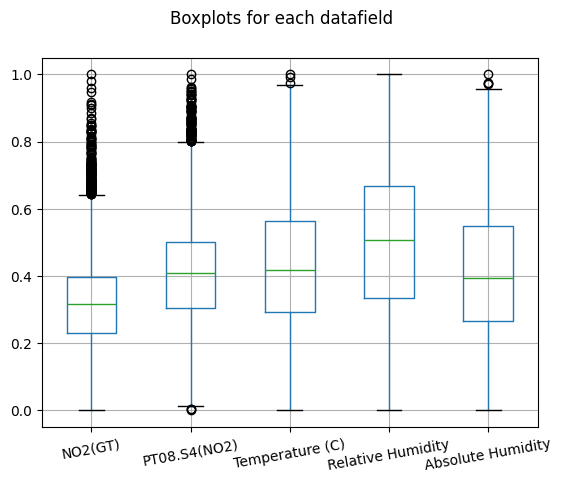

In [7]:
df[columns_of_interest].boxplot()
plt.suptitle("Boxplots for each datafield")
plt.xticks(rotation=10)
plt.show()


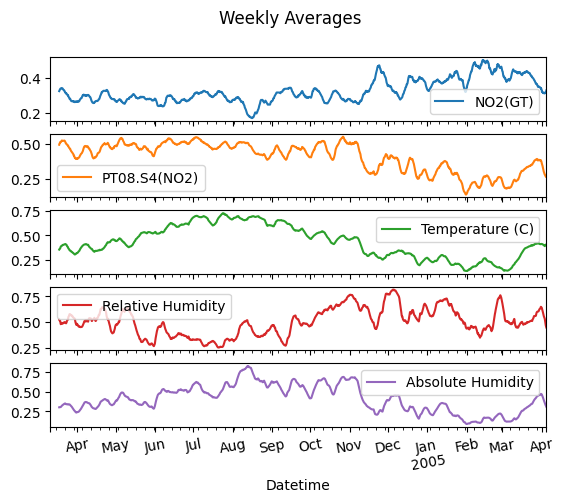

In [8]:
weekly_average = df.copy()
weekly_average[columns_of_interest] = df[columns_of_interest].rolling(7 * 24).mean()

weekly_average.plot("Datetime", columns_of_interest, subplots=True)
plt.suptitle("Weekly Averages")
plt.xticks(rotation=10)
plt.show()


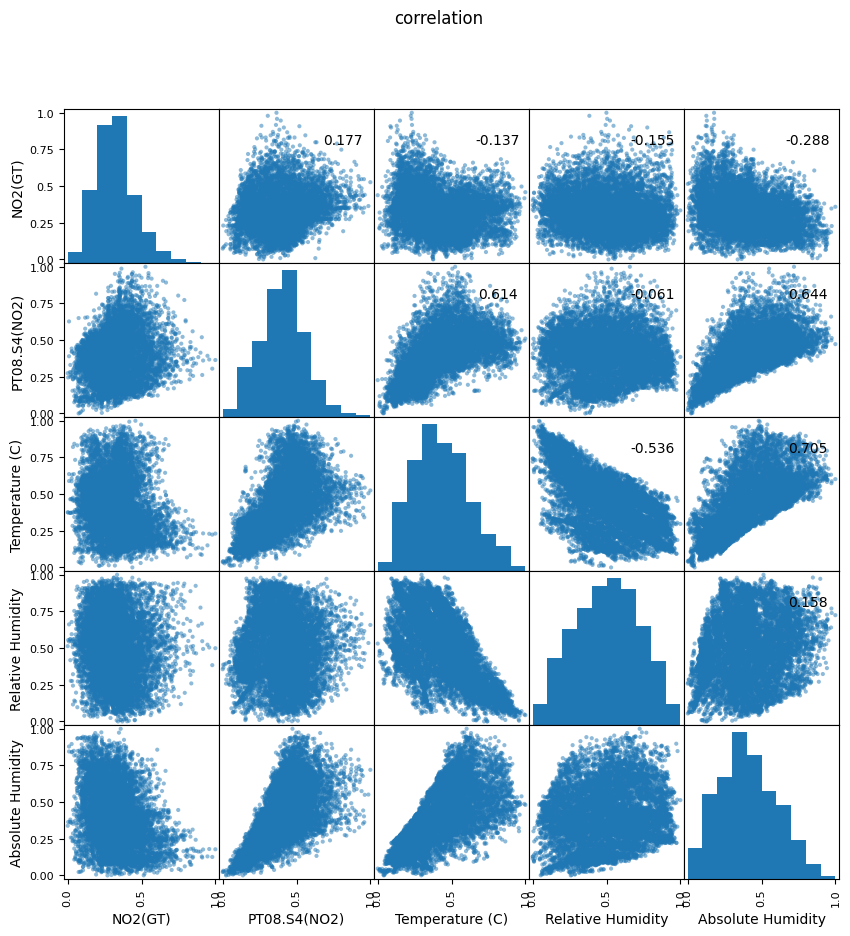

In [9]:
axes = pd.plotting.scatter_matrix(df[columns_of_interest], alpha=0.5, figsize=[10, 10])
corr = df[columns_of_interest].corr(method="spearman").to_numpy()

for i, j in zip(*np.triu_indices_from(corr, k=1)):
    axes[i, j].annotate("%.3f" % corr[i, j], (0.8, 0.8),
                        xycoords="axes fraction", ha="center", va="center")

plt.suptitle("correlation")
plt.show()


In [10]:
"""
NO2 changes much more over time than temperature or humidity and follows time-based patterns.

The sensor readings closely match the actual NO2 values meaning the sensor is reliable.

Short-term spikes and long-term shifts appear in the data. Can be seen especially after smoothing.

This supports using linear regression as a baseline and timeseries models for better accuracy
"""

'\nNO2 changes much more over time than temperature or humidity and follows time-based patterns.\n\nThe sensor readings closely match the actual NO2 values meaning the sensor is reliable.\n\nShort-term spikes and longer-term shifts appear in the data. Can be seen especially after smoothing.\n\nThis supports using linear regression as a baseline and timeseries models for better accuracy.\n'

In [11]:
corr_df = df[columns_of_interest].corr(method="spearman")
corr_df


,NO2(GT),PT08.S4(NO2),Temperature (C),Relative Humidity,Absolute Humidity
NO2(GT),1.000000,0.177217,-0.136525,-0.155191,-0.287865
PT08.S4(NO2),0.177217,1.000000,0.614026,-0.060738,0.643825
Temperature (C),-0.136525,0.614026,1.000000,-0.536289,0.704901
Relative Humidity,-0.155191,-0.060738,-0.536289,1.000000,0.157820
Absolute Humidity,-0.287865,0.643825,0.704901,0.157820,1.000000


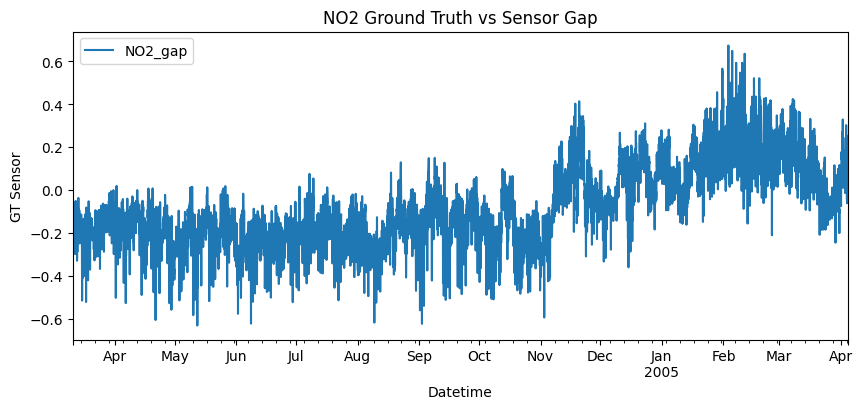

In [12]:
df["NO2_gap"] = df["NO2(GT)"] - df["PT08.S4(NO2)"]

df.plot("Datetime", "NO2_gap", figsize=(10, 4))
plt.title("NO2 Ground Truth vs Sensor Gap")
plt.ylabel("GT Sensor")
plt.show()


In [15]:
"""
The difference between the ground truth and the sensor reading shifts over time.
 This means the sensor does not have a fixed error and can drift under changing conditions.
Because this gap is not stable a predictive model can learn the patterns and provide more accurate NO2 est.
"""

'\nThe difference between the ground truth and the sensor reading shifts over time.\n This means the sensor does not have a fixed error and can drift under changing conditions.\nBecause this gap is not stable a predictive model can learn the patterns and provide more accurate NO2 est.\n'